## Digit Recognition Project CNN

In [43]:
import tensorflow as tf

In [44]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras import datasets
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential, layers


In [45]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

Text(0.5, 1.0, 'lable : 5')

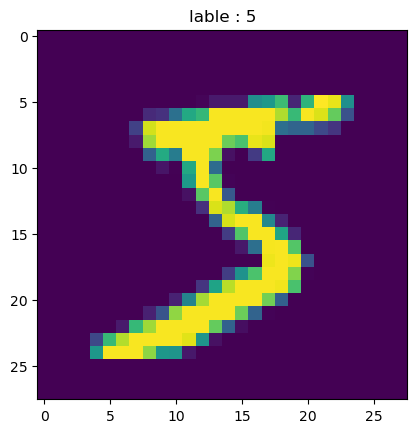

In [46]:
plt.imshow(x_train[0])
plt.title(f"lable : {y_train[0]}")

In [47]:
x_train / 255
x_test / 255
x_train.reshape((60000, 28,28,1))
x_test.reshape((10000, 28,28,1))

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [48]:
from tensorflow.keras import Sequential, layers

model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),  
    layers.Dense(10, activation='softmax')  
])


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']                   
)


In [56]:
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data = (x_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9879 - loss: 0.0392 - val_accuracy: 0.9908 - val_loss: 0.0343
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9904 - val_loss: 0.0377
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9935 - loss: 0.0207 - val_accuracy: 0.9889 - val_loss: 0.0392
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9904 - val_loss: 0.0405
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9893 - val_loss: 0.0445
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9932 - loss: 0.0225 - val_accuracy: 0.9880 - val_loss: 0.0467
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9936 - loss: 0.0213 - val_accuracy: 0.9880 - val_loss: 0.0493
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9947 - loss: 0.0179 - val_acc

In [57]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0515


In [58]:
prediction = model.predict(x_test)
print(prediction)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1.3157280e-17 5.5852806e-15 2.2742312e-11 ... 1.0000000e+00
  2.1493828e-11 3.1827738e-11]
 [7.3688634e-14 2.7327295e-18 1.0000000e+00 ... 3.6629390e-18
  5.4886132e-21 4.1236616e-28]
 [8.0001828e-14 1.0000000e+00 3.1984834e-17 ... 3.4972955e-10
  6.5684166e-11 5.1982751e-15]
 ...
 [2.6236508e-27 5.9153774e-19 2.9722421e-24 ... 1.6893209e-22
  7.0458662e-17 1.4847168e-14]
 [2.2764486e-30 2.0327040e-28 2.3259691e-27 ... 2.1985623e-30
  9.1685197e-20 6.1471788e-17]
 [3.6483504e-19 4.3277762e-22 6.1351220e-22 ... 2.9004131e-31
  4.8838232e-18 2.1679800e-23]]


In [59]:
model.save("digit_recognition_project_cnn.h5")